In [55]:
import tkinter as tk
from tkinter import messagebox
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [35]:
df = pd.read_csv(r"C:\Users\HP\Downloads\Lung Cancer Dataset.csv")
df

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,PULMONARY_DISEASE
0,68,1,1,1,1,1,0,57.831178,0,0,1,1,95.977287,1,0,0,0,NO
1,81,1,1,0,0,1,1,47.694835,1,1,0,1,97.184483,0,0,0,0,YES
2,58,1,1,0,0,0,0,59.577435,0,1,1,0,94.974939,0,0,0,0,NO
3,44,0,1,0,1,1,0,59.785767,0,1,0,1,95.187900,0,0,0,0,YES
4,72,0,1,1,1,1,1,59.733941,0,1,0,1,93.503008,0,0,0,0,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,32,0,1,1,0,0,1,60.700696,1,1,1,1,94.012495,0,1,1,0,YES
4996,80,0,1,1,1,1,1,50.751741,0,1,1,1,94.394968,0,0,0,0,YES
4997,51,1,0,0,1,0,0,61.063496,1,0,0,0,98.108901,0,0,0,1,NO
4998,76,1,0,1,0,0,0,48.662872,0,1,0,1,95.577773,1,0,0,0,NO


In [36]:
df.isnull().sum()

AGE                       0
GENDER                    0
SMOKING                   0
FINGER_DISCOLORATION      0
MENTAL_STRESS             0
EXPOSURE_TO_POLLUTION     0
LONG_TERM_ILLNESS         0
ENERGY_LEVEL              0
IMMUNE_WEAKNESS           0
BREATHING_ISSUE           0
ALCOHOL_CONSUMPTION       0
THROAT_DISCOMFORT         0
OXYGEN_SATURATION         0
CHEST_TIGHTNESS           0
FAMILY_HISTORY            0
SMOKING_FAMILY_HISTORY    0
STRESS_IMMUNE             0
PULMONARY_DISEASE         0
dtype: int64

In [37]:
df['PULMONARY_DISEASE'].unique()

array(['NO', 'YES'], dtype=object)

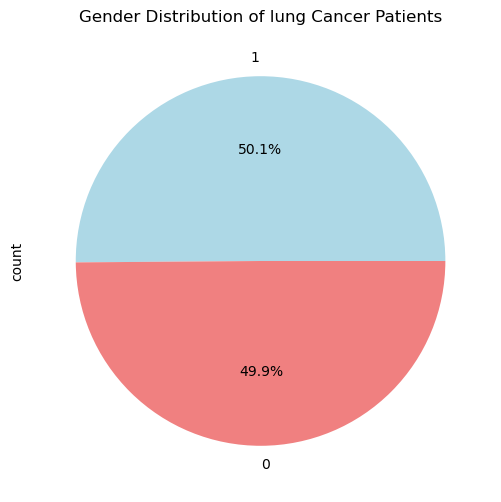

In [38]:
plt.figure(figsize=(6, 6))
df["GENDER"].value_counts().plot.pie(autopct="%1.1f%%", colors=["lightblue", "lightcoral"])
plt.title("Gender Distribution of lung Cancer Patients")
plt.show()

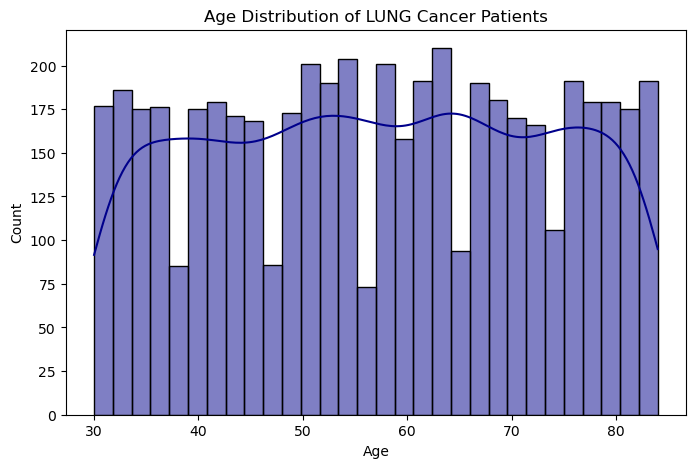

In [39]:
# Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["AGE"], bins=30, kde=True, color="darkblue")
plt.title("Age Distribution of LUNG Cancer Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

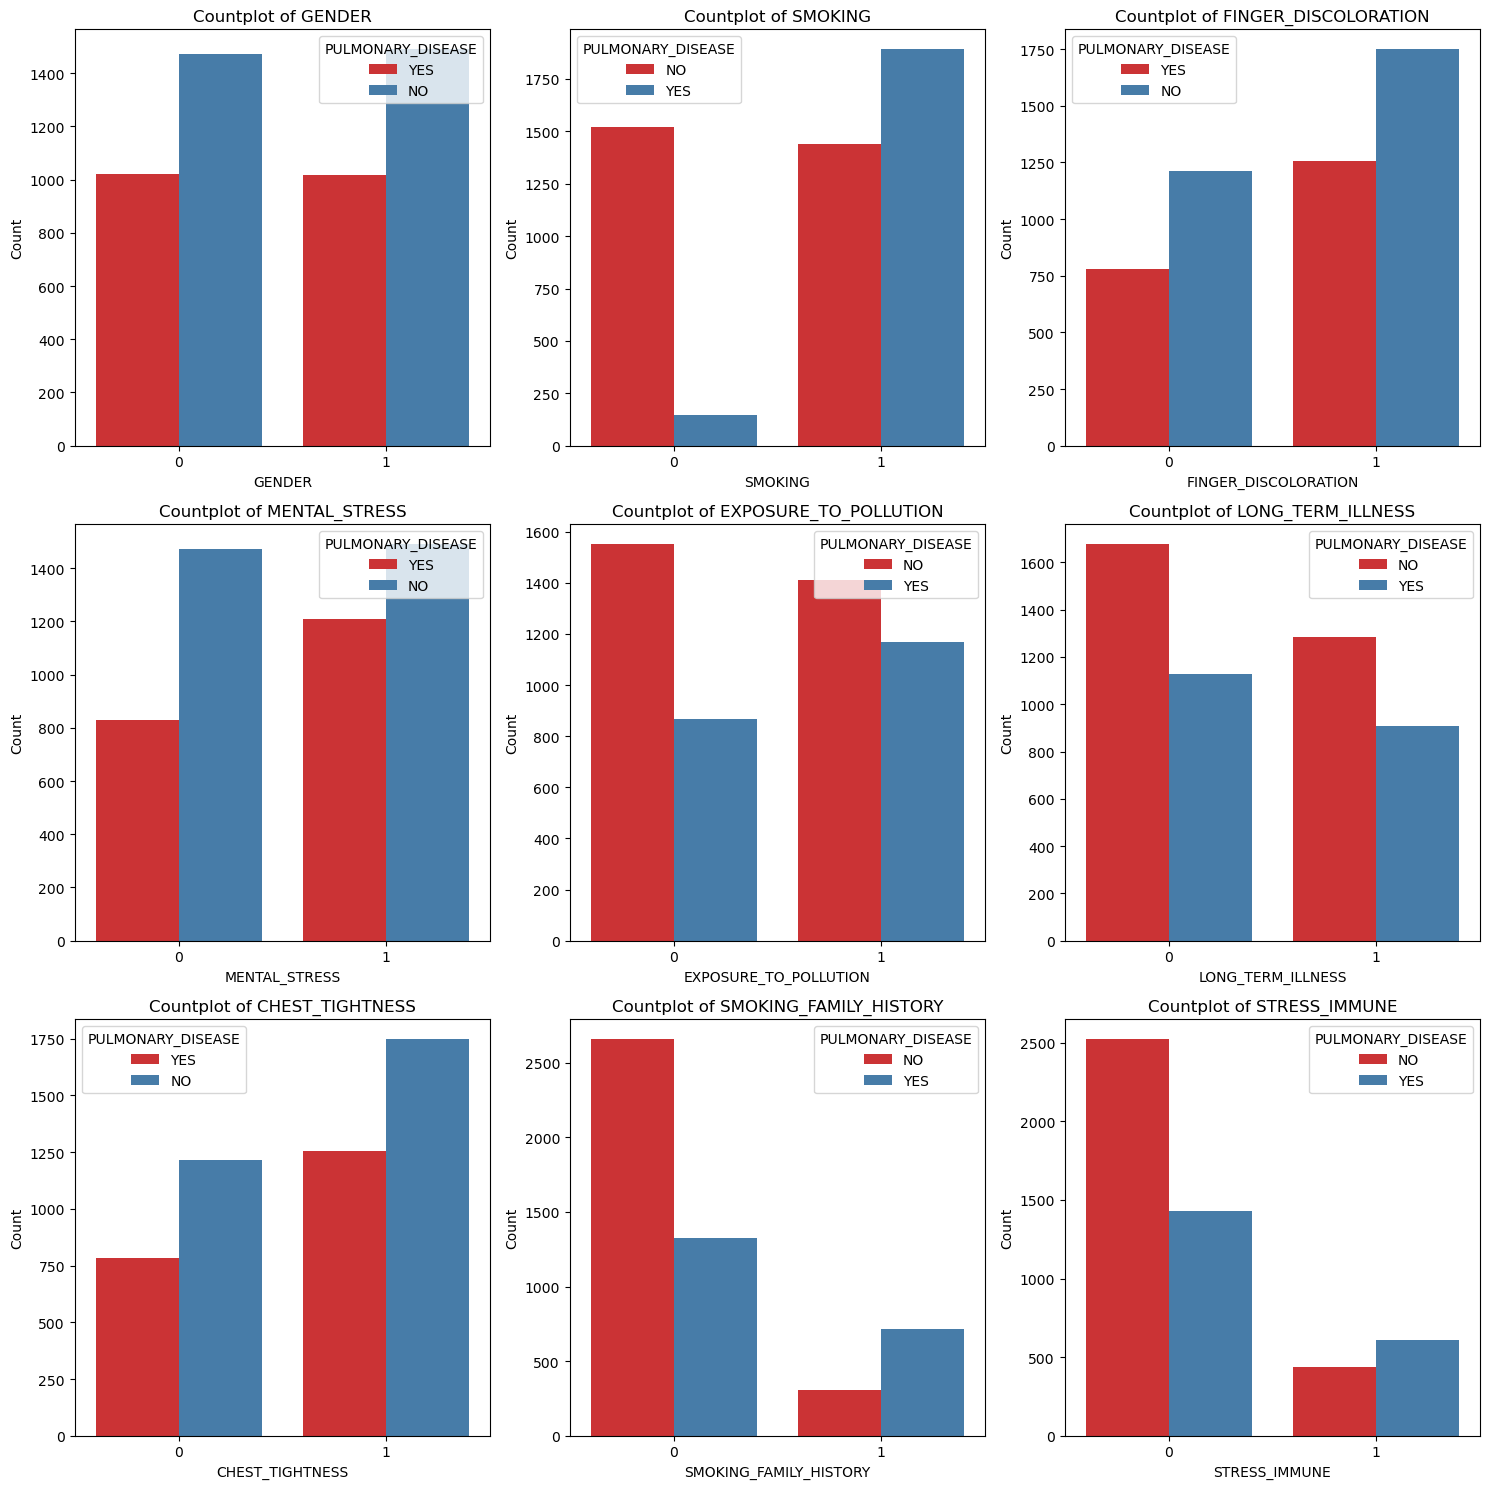

In [40]:


# الأعمدة التي نرسمها
cols = ['GENDER','SMOKING','FINGER_DISCOLORATION','MENTAL_STRESS',
        'EXPOSURE_TO_POLLUTION','LONG_TERM_ILLNESS','CHEST_TIGHTNESS',
        'SMOKING_FAMILY_HISTORY','STRESS_IMMUNE']

# إنشاء الرسم (3 صفوف × 3 أعمدة)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
axes = axes.flatten()  # تحويل axes من 2D إلى 1D لسهولة الاستخدام

palette = 'Set1'
for i, feature in enumerate(cols):  # ← لازم تستخدم cols مش features
    sns.countplot(x=feature, hue='PULMONARY_DISEASE', data=df, ax=axes[i],palette=palette)
    axes[i].set_title(f'Countplot of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')


plt.tight_layout()
plt.show()


In [41]:
label_encoders = {}
for column in df.columns:
    if df[column].dtype == "object":
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le

In [42]:
x = df.drop('PULMONARY_DISEASE', axis=1)
y = df['PULMONARY_DISEASE']
x

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE
0,68,1,1,1,1,1,0,57.831178,0,0,1,1,95.977287,1,0,0,0
1,81,1,1,0,0,1,1,47.694835,1,1,0,1,97.184483,0,0,0,0
2,58,1,1,0,0,0,0,59.577435,0,1,1,0,94.974939,0,0,0,0
3,44,0,1,0,1,1,0,59.785767,0,1,0,1,95.187900,0,0,0,0
4,72,0,1,1,1,1,1,59.733941,0,1,0,1,93.503008,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,32,0,1,1,0,0,1,60.700696,1,1,1,1,94.012495,0,1,1,0
4996,80,0,1,1,1,1,1,50.751741,0,1,1,1,94.394968,0,0,0,0
4997,51,1,0,0,1,0,0,61.063496,1,0,0,0,98.108901,0,0,0,1
4998,76,1,0,1,0,0,0,48.662872,0,1,0,1,95.577773,1,0,0,0


In [43]:
y

0       0
1       1
2       0
3       1
4       1
       ..
4995    1
4996    1
4997    0
4998    0
4999    0
Name: PULMONARY_DISEASE, Length: 5000, dtype: int32

In [44]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)


In [45]:
model = GaussianNB()
model.fit(x_train, y_train)

GaussianNB()

In [46]:
model.score(x_test, y_test)

0.8533333333333334

In [47]:
y_pred = model.predict(x_test)

In [48]:
conf_matrix = confusion_matrix(y_test, y_pred)


target_names = label_encoders['PULMONARY_DISEASE'].classes_.astype(str)

class_report = classification_report(y_test, y_pred, target_names=target_names)

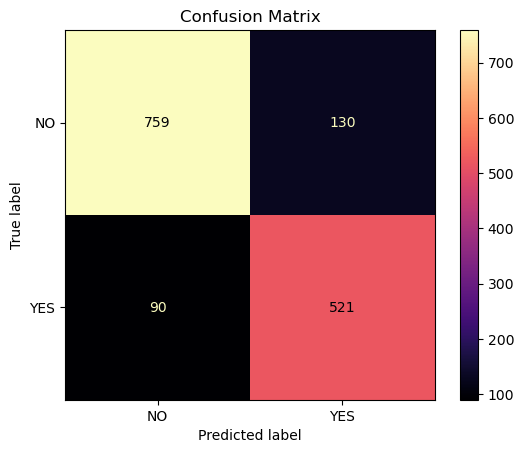

In [49]:
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=label_encoders['PULMONARY_DISEASE'].classes_)
disp.plot(cmap='magma', values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [50]:
feature_names = x.columns.tolist()

In [51]:
root = tk.Tk()
root.title("تشخيص مرض الرئة")
entries = {}

In [52]:
def predict():
    try:
        user_input = []
        for feature in feature_names:
            val = entries[feature].get().strip().lower()
            if val == "yes":
                user_input.append(1)
            elif val == "no":
                user_input.append(0)
            else:
                user_input.append(float(val))  # يقبل أرقام مثل العمر أو نسبة الأكسجين
        input_array = np.array(user_input).reshape(1, -1)
        prediction = model.predict(input_array)[0]
        result = label_encoders['PULMONARY_DISEASE'].inverse_transform([prediction])[0]
        messagebox.showinfo("النتيجة", f"التشخيص: {result}")
    except Exception as e:
        messagebox.showerror("خطأ", f"حدث خطأ في الإدخال: {e}")

In [53]:
for idx, feature in enumerate(feature_names):
    label = tk.Label(root, text=feature)
    label.grid(row=idx, column=0, padx=5, pady=5, sticky='e')
    entry = tk.Entry(root)
    entry.grid(row=idx, column=1, padx=5, pady=5)
    entries[feature] = entry

In [54]:
btn = tk.Button(root, text="تشخيص", command=predict)
btn.grid(row=len(feature_names), columnspan=2, pady=10)

root.mainloop()